In [1]:
from limited_data_experiment import (
    score_oracle,
    load_experiments_data_thm,
)
import numpy as np


ALL_RUNS = [31, 32, 33, 53, 54]

/home/porepy/porepy/src/porepy/numerics/nonlinear/nonlinear_solvers.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange  # type: ignore


In [2]:
cv_results, scoring = score_oracle(load_experiments_data_thm, ALL_RUNS, n_jobs=1)

for score in scoring:
    print(score)
    print("Train scores:", cv_results[f"train_{score}"])
    print("Test scores:", cv_results[f"test_{score}"])
    print("Mean Train:", np.mean(cv_results[f"train_{score}"]))
    print("Mean Test:", np.mean(cv_results[f"test_{score}"]))
    print()

Scoring oracle
mae_success
Train scores: [-0.06998644 -0.06949328 -0.06856512 -0.0703589  -0.06916471]
Test scores: [-0.07009958 -0.07074669 -0.07020565 -0.07057079 -0.07017554]
Mean Train: -0.06951369060798304
Mean Test: -0.0703596508493934

r2_success
Train scores: [0.88856579 0.88673678 0.89903378 0.87851211 0.89372793]
Test scores: [0.88215218 0.88968535 0.867574   0.89595267 0.87725095]
Mean Train: 0.8893152778662834
Mean Test: 0.8825230303906425

acc_failure
Train scores: [0.96980108 0.97086143 0.97043854 0.97014166 0.97069302]
Test scores: [0.9706531  0.96675148 0.9697998  0.97013912 0.96793349]
Mean Train: 0.9703871461744853
Mean Test: 0.9690553985551358

f1_failure
Train scores: [0.95276635 0.9547401  0.95389907 0.95338983 0.95399774]
Test scores: [0.95434151 0.94702703 0.95245726 0.95351294 0.95107429]
Mean Train: 0.9537586177051022
Mean Test: 0.9516826087810031



In [3]:
from limited_data_experiment import (
    do_experiment,
    load_experiments_data_thm,
)
from itertools import count
import multiprocessing as mp
from functools import partial

GAMMA_VALS = [
    0.05,
    0.1,
    0.5,
    1,
]
EPS_VALS = [
    0,
    0.1,
    0.5,
    0.9,
]

experiment_setups = []

for seq_id in ALL_RUNS:
    for gamma in GAMMA_VALS:
        for eps in EPS_VALS:
            experiment_setups.append(
                {
                    "incremental_learning": True,
                    "one_decision": False,
                    "seq_id": seq_id,
                    "gamma": gamma,
                    "eps": eps,
                    "batch_size": 128,
                }
            )

    for one_decision in [False, True]:
        experiment_setups.append(
            {
                "incremental_learning": False,
                "one_decision": one_decision,
                "seq_id": seq_id,
                "gamma": 1,
                "eps": 0,
                "batch_size": 128,
            }
        )

cnt = count()
for experiment in experiment_setups:
    experiment["experiment_idx"] = next(cnt)
    experiment["experiments_total"] = len(experiment_setups)

num_processes = mp.cpu_count()
print(f"{num_processes = }")
with mp.Pool(num_processes) as pool:
    results = pool.map(partial(do_experiment, load_experiments_data=partial(load_experiments_data_thm, dir="../stats/"), all_run_ids=ALL_RUNS), experiment_setups)


# results = [do_experiment(x, load_experiments_data=partial(load_experiments_data_thm, dir="../stats/")) for x in experiment_setups]

num_processes = 16


Start experiment 12 / 90
Start experiment 4 / 90Start experiment 26 / 90Start experiment 20 / 90


Start experiment 2 / 90
Start experiment 22 / 90
Start experiment 0 / 90
Start experiment 24 / 90
Start experiment 8 / 90
Start experiment 30 / 90
Start experiment 16 / 90
Start experiment 14 / 90
Start experiment 10 / 90
Start experiment 6 / 90
Start experiment 28 / 90
Start experiment 18 / 90
Done experiment 16 / 90
Start experiment 17 / 90
Done experiment 17 / 90
Start experiment 32 / 90
Done experiment 20 / 90
Done experiment 22 / 90
Done experiment 0 / 90
Done experiment 4 / 90
Done experiment 6 / 90
Done experiment 8 / 90
Done experiment 10 / 90
Start experiment 21 / 90
Done experiment 18 / 90
Start experiment 23 / 90
Done experiment 28 / 90
Done experiment 2 / 90
Start experiment 1 / 90
Done experiment 24 / 90
Start experiment 5 / 90
Start experiment 11 / 90
Start experiment 7 / 90
Start experiment 9 / 90
Done experiment 26 / 90
Start experiment 19 / 90
Start experiment 29 / 90
Sta

In [4]:
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib

matplotlib.rcdefaults()

# tex_fonts = {
#     # Use LaTeX to write all text
#     # "text.usetex": True,
#     "font.family": "serif",
#     "axes.labelsize": 10,
#     "font.size": 10,
#     # Make the legend/label fonts a little smaller
#     "legend.fontsize": 9,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9,
# }

# sns.set_theme(
#     # context="talk",
#     context="paper",
#     # rc={"figure.figsize": (8, 6)},
#     # palette="colorblind6",
#     style="whitegrid",
#     rc=tex_fonts,
# )

In [5]:
from collections import defaultdict
import numpy as np
import pandas as pd


data_for_pandas = defaultdict(lambda: [])
for result in results:
    data_for_pandas["incremental_learning"].append(result["incremental_learning"])
    data_for_pandas["one_decision"].append(result["one_decision"])
    data_for_pandas["seq_id"].append(result["seq_id"])
    data_for_pandas["gamma"].append(result["gamma"])
    data_for_pandas["eps"].append(result["eps"])
    data_for_pandas["batch_size"].append(result["batch_size"])
    data_for_pandas["NTS"].append((result["NTS"]))
    data_for_pandas["TopEPS"].append((result["TopEPS"]))
    data_for_pandas["mean_NTS"].append(np.mean(result["NTS"]))
    data_for_pandas["mean_TopEPS"].append(np.mean(result["TopEPS"]))
    data_for_pandas['ypred'].append(result['ypred'])
    data_for_pandas['yoracle'].append(result['yoracle'])
    data_for_pandas['yfeedback'].append(result['yfeedback'])
    data_for_pandas['tpred'].append(result['tpred'])
    data_for_pandas['tfeedback'].append(result['tfeedback'])
    data_for_pandas['decision_id'].append(result['decision_id'])


df = pd.DataFrame(data_for_pandas)
df.head(1)

,incremental_learning,one_decision,seq_id,gamma,eps,batch_size,NTS,TopEPS,mean_NTS,mean_TopEPS,ypred,yoracle,yfeedback,tpred,tfeedback,decision_id
0,True,False,31,0.05,0.0,128,"[0.9167622952019636, 0.05510910858135731, 0.05...","[True, False, False, False, False, False, Fals...",0.976496,0.947445,"[-1.3141719120016881, -100.0, -100.0, -100.0, ...","[-1.5770216168464766, -1.5770216168464766, -1....","[-1.5942113749545919, -1.7721548909012779, -1....","[0.0016281604766845703, 0.0006425380706787109,...","[2.384185791015625e-06, 1.9073486328125e-06, 2...","[163, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."


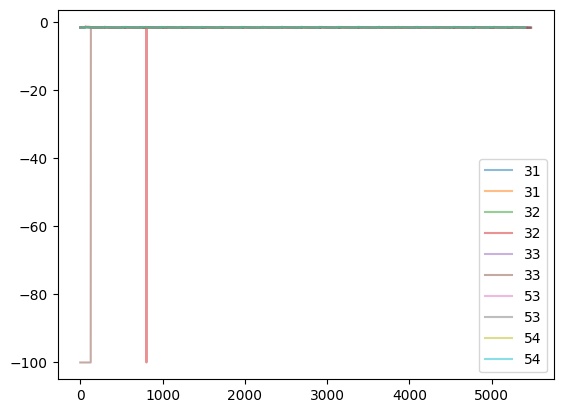

In [6]:
from matplotlib import pyplot as plt

for row in df[(df.eps == 0) & (df.gamma == 1) & (df.incremental_learning) & ~df.one_decision].itertuples(index=False):
    plt.plot((row.yoracle), label=row.seq_id, alpha=0.5)
    plt.plot((row.ypred), label=row.seq_id, alpha=0.5)
plt.legend()


In [7]:
df_heatmap = df[(df.incremental_learning) & ~(df.one_decision)]
# df_heatmap = df_heatmap.groupby(["eps", 'gamma'])["mean_TopEPS"].agg(["mean", 'std']).unstack()
df_heatmap = df_heatmap.groupby(["eps", 'gamma'])["mean_NTS"].agg(["mean", 'std']).unstack()

df_heatmap

mean                                     std                      \
gamma      0.05      0.10      0.50      1.00      0.05      0.10      0.50   
eps                                                                           
0.0    0.802830  0.858794  0.896244  0.866453  0.097655  0.109605  0.107182   
0.1    0.972926  0.973457  0.961228  0.975023  0.006054  0.009479  0.023169   
0.5    0.973626  0.974129  0.959399  0.973634  0.003988  0.007125  0.019912   
0.9    0.973062  0.971908  0.962999  0.961184  0.005104  0.006350  0.018557   

                 
gamma      1.00  
eps              
0.0    0.114026  
0.1    0.009851  
0.5    0.004522  
0.9    0.020003

In [8]:
annot = df_heatmap['mean'].round(2).astype(str) + "±" + df_heatmap['std'].round(2).astype(str)
annot

gamma,0.05,0.10,0.50,1.00
eps,,,,
0.0,0.8±0.1,0.86±0.11,0.9±0.11,0.87±0.11
0.1,0.97±0.01,0.97±0.01,0.96±0.02,0.98±0.01
0.5,0.97±0.0,0.97±0.01,0.96±0.02,0.97±0.0
0.9,0.97±0.01,0.97±0.01,0.96±0.02,0.96±0.02


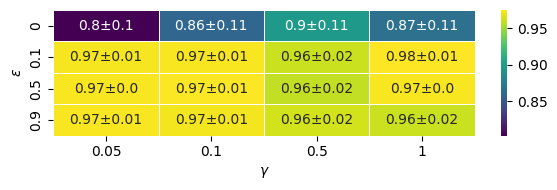

In [9]:
plt.figure(figsize=(6, 2))
sns.heatmap(
    np.array(df_heatmap["mean"]),
    # np.array(df_heatmap["std"]),
    annot=np.array(annot),
    cmap="viridis",
    linecolor="white",
    linewidths=0.5,
    yticklabels=EPS_VALS,
    xticklabels=GAMMA_VALS,
    fmt="",
)
plt.ylabel(r"$\varepsilon$")
plt.xlabel(r"$\gamma$")
# plt.title(r"Top-$\varepsilon$ Acc.", fontweight="bold")
plt.tight_layout()
# plt.savefig("scenarioA_topeps.pdf")

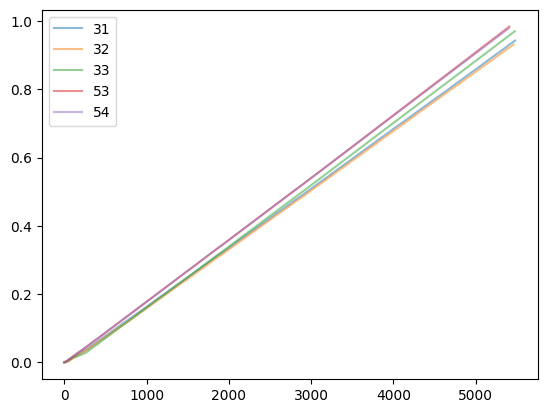

In [10]:
from matplotlib import pyplot as plt

for row in df[(df.eps == 0.1) & (df.gamma == 0.5) & (df.incremental_learning) & ~df.one_decision].itertuples(index=False):
    # plt.plot((row.NTS), label=row.seq_id, alpha=0.5)

    # plt.plot(np.cumsum(row.TopEPS) / np.size(row.TopEPS), label=row.seq_id, alpha=0.5)
    plt.plot(np.cumsum(row.NTS) / np.size(row.NTS), label=row.seq_id, alpha=0.5)

plt.legend()


In [11]:
df_special = df[~df.incremental_learning]
df_special = df_special.groupby('one_decision')[["mean_TopEPS", 'mean_NTS']].agg(["mean", 'std'])
df_special

mean_TopEPS            mean_NTS          
                    mean       std      mean       std
one_decision                                          
False                0.4  0.547723  0.749847  0.258526
True                 0.4  0.547723  0.779908  0.246636

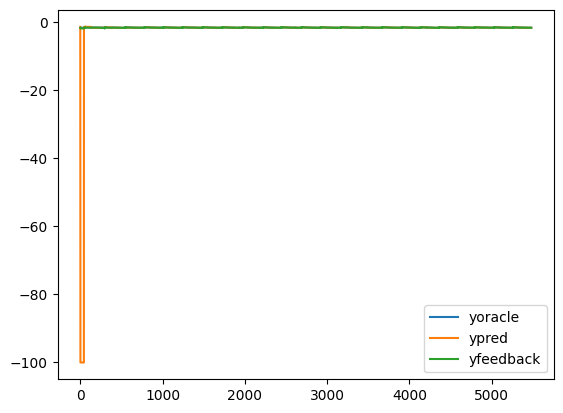

In [12]:
for row in df[:1].itertuples(index=False):
    # plt.plot(np.cumsum(row.tfeedback + row.tpred))
    plt.plot(row.yoracle, label='yoracle')
    plt.plot(row.ypred, label='ypred')
    plt.plot(row.yfeedback, label='yfeedback')

plt.legend()

/tmp/ipykernel_1885143/569567501.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'ML overhead, s')

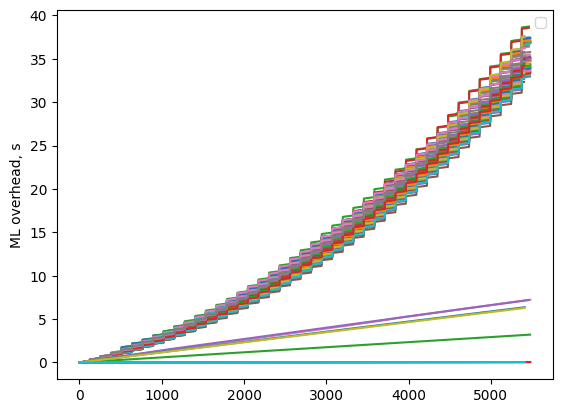

In [13]:
for row in df[:].itertuples(index=False):
    plt.plot(np.cumsum(row.tfeedback + row.tpred))

plt.legend()
plt.ylabel('ML overhead, s')